# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Low Yi Qing



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [4]:
## import libraries
import pandas as pd
import numpy as np

# data visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

# train-test split
from sklearn.model_selection import train_test_split

# classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# 1. Business Understanding
Goal: To predict whether a hotel booking will be cancelled before the guest's arrival based on booking information such as lead time, customer type, market segment, booking changes, previous cancellations, average daily rate (ADR), and other reservation-related features. This enables hotels to identify high-risk bookings early and take proactive measures to reduce revenue loss, optimise room allocation, and improve operational planning.

# 2. Data Understanding

## 2.1 Load dataset

In [6]:
## Read *.csv file into pandas DataFrame
FILE_PATH= "hotel_booking.csv"
df = pd.read_csv(FILE_PATH) 
df 

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860


## 2.2 Summary Statistics

In [7]:
## ensure that all data is imported
df.shape

(119390, 36)

In [15]:
# display the first 5 rows of the dataset
# helps to quickly inspect the data structure and verify that it was loaded correctly
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [ ]:
# display dataset information (columns, data types, and missing values)
# helps identify data types and missing values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
# count the number of missing values in each column
# helps identify which columns require missing value treatment
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [13]:
# display summary statistics for numerical features
# helps understand the data distribution and identify potential outliers
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [16]:
# check for number of duplicate rows
# helps identify duplicate records that may affect model performance
df.duplicated().sum()

np.int64(0)

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

Number of bookings by cancellation status:
is_canceled
0    75166
1    44224
Name: count, dtype: int64
Percentage of bookings by cancellation status:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


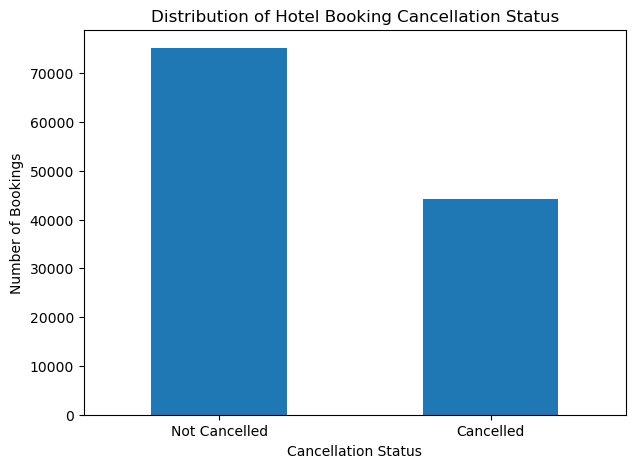

In [17]:
# display the number of bookings in each target class
# to check whether cancelled and non-cancelled bookings are balanced
# 0 = Not Cancelled, 1 = Cancelled
target_counts = df['is_canceled'].value_counts().sort_index()

print("Number of bookings by cancellation status:")
print(target_counts)

# calculate the percentage distribution of the target classes
# so the level of class imbalance can be interpreted more clearly
target_percentages = (
    df['is_canceled']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Percentage of bookings by cancellation status:")
print(target_percentages.round(2))


# plot distribution of the target variable to visually 
# compare cancelled and non cancelled bookings
target_counts.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Distribution of Hotel Booking Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Bookings')

# replace the numerical target labels with meaningful business labels
# so the chart is easier to understand
plt.xticks(
    ticks=[0, 1],
    labels=['Not Cancelled', 'Cancelled'],
    rotation=0
)

plt.show()

The target variable shows that 75,166 bookings (62.96%) were not cancelled, while 44,224 bookings (37.04%) were cancelled. Although the dataset is not perfectly balanced, both classes are well represented, making it suitable for building and evaluating classification models. This distribution also suggests that relying solely on accuracy may not be sufficient, so additional evaluation metrics such as precision, recall and F1-score will be used later to assess model performance.

### 2.3.1.2 Understanding distribution of features

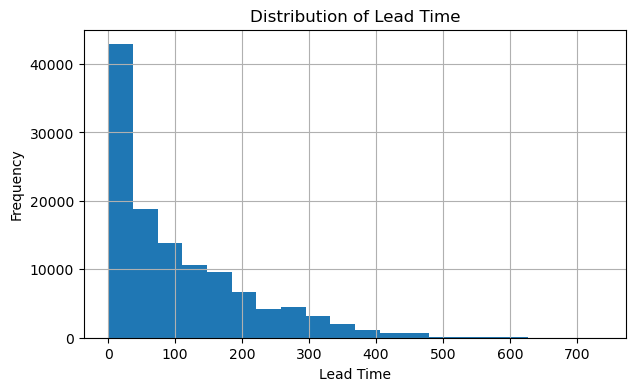

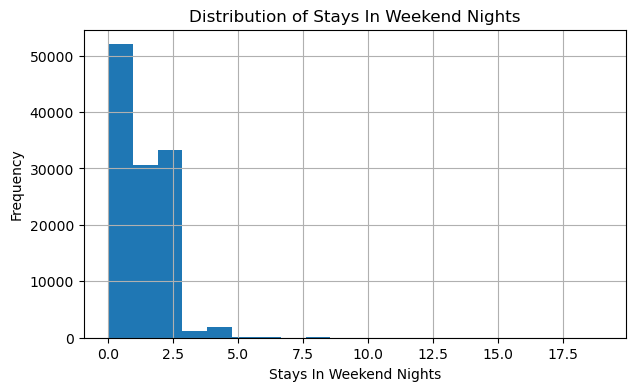

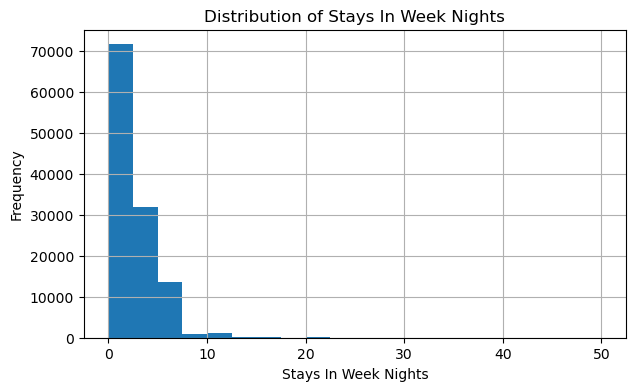

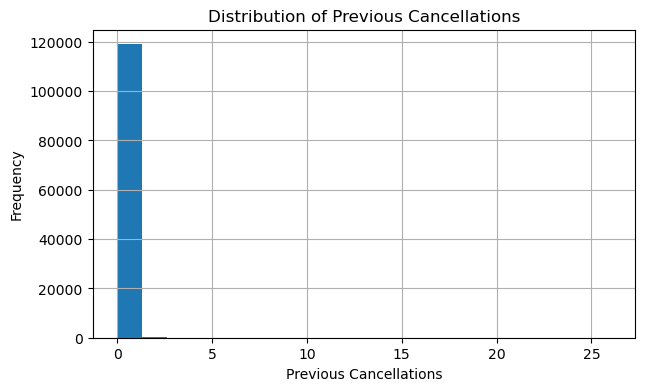

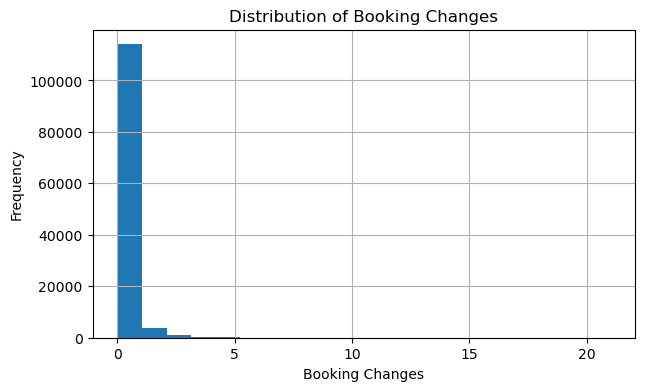

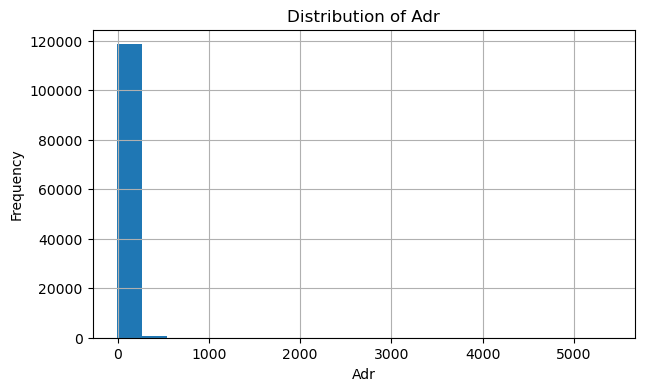

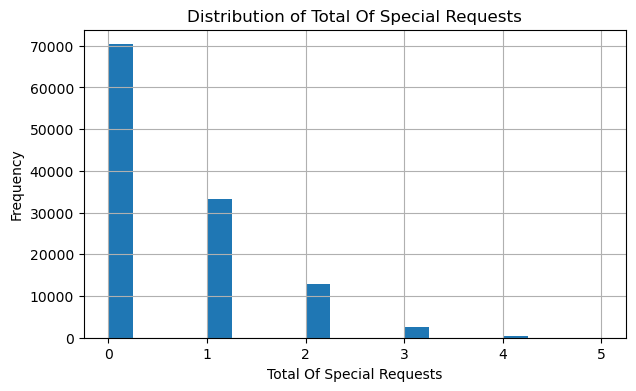

In [18]:
# select numerical features for analysis
# to understand their distributions and identify any skewness,
# unusual values or potential outliers before model development
numerical_features = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'previous_cancellations',
    'booking_changes',
    'adr',
    'total_of_special_requests'
]

# plot a histogram for each numerical feature to visualise
# how the values are distributed across all hotel bookings
for column in numerical_features:

    plt.figure(figsize=(7,4))

    df[column].hist(bins=20)

    plt.title(f"Distribution of {column.replace('_',' ').title()}")
    plt.xlabel(column.replace('_',' ').title())
    plt.ylabel("Frequency")

    plt.show()

Most of the numerical features are positively skewed, where the majority of  bookings are concentrated at lower values with fewer bookings at highe values.Features such as lead_time, stays_in_weekend_nights, stays_in_week_nights, booking_changes, and previous_cancellations show that most bookings have relatively small values. The ADR feature also seems to contain a few unusually large values, showing the presence of potential outliers. These observations suggest that the numerical features have different distributions, which will be considered during data preprocessing and model evaluation.

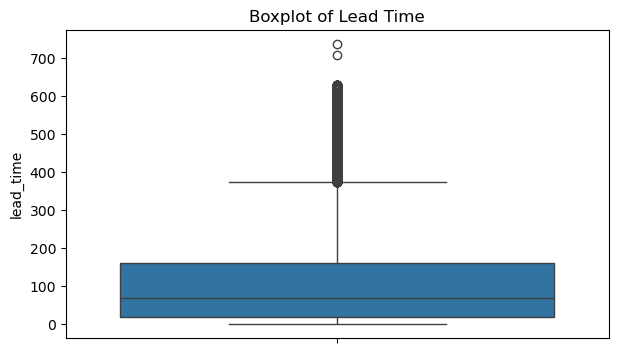

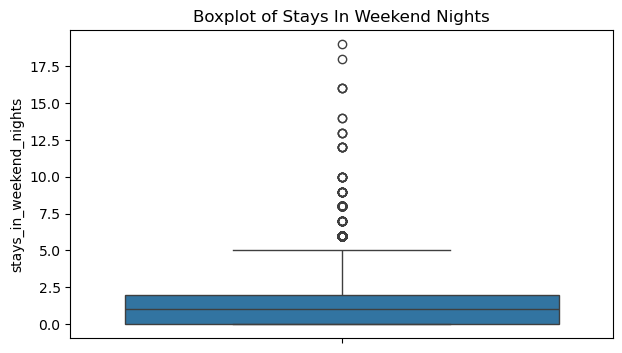

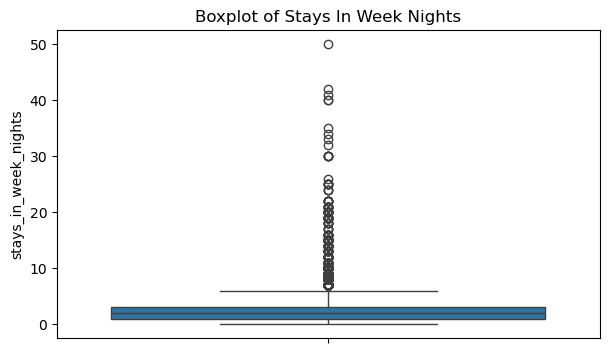

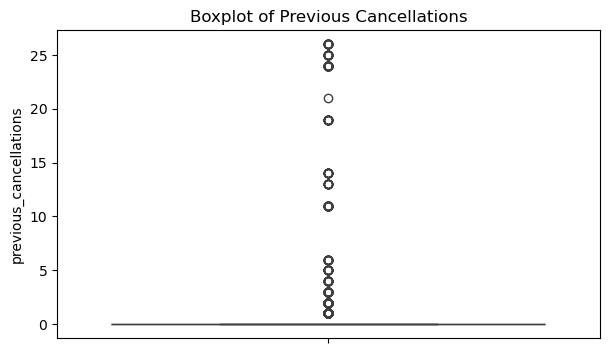

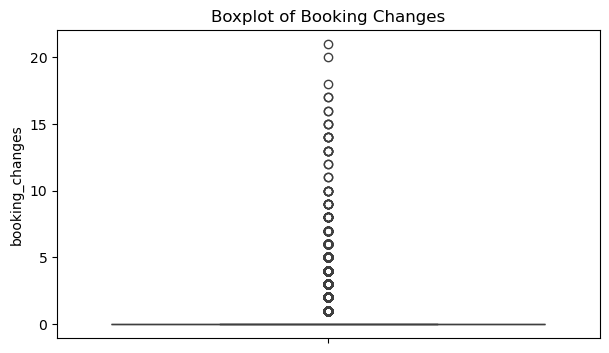

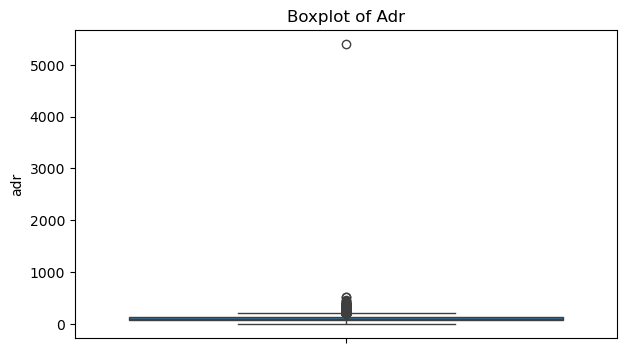

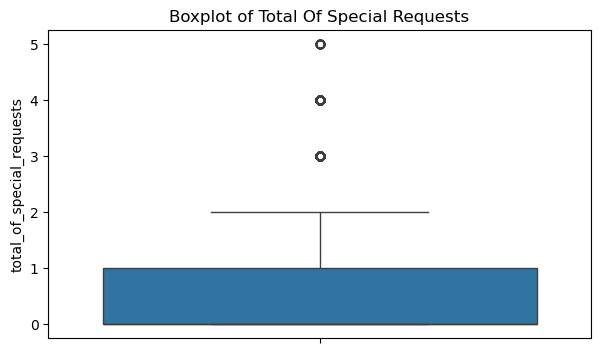

In [19]:
# plot boxplots for each numerical feature to identify
# potential outliers and compare the spread of the data.
# this helps determine whether extreme values are present
# before building the machine learning models.
for column in numerical_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(y=df[column])

    plt.title(f"Boxplot of {column.replace('_',' ').title()}")

    plt.show()

The boxplots indicate outliers may be present in several numerical features, particularly ADR, Lead Time, Booking Changes, and Previous Cancellations. As these values may represent genuine hotel booking behaviour rather than data entry errors, they will be retained for model training. This is especially since tree-based models such as Random Forest are generally less affected by outliers.

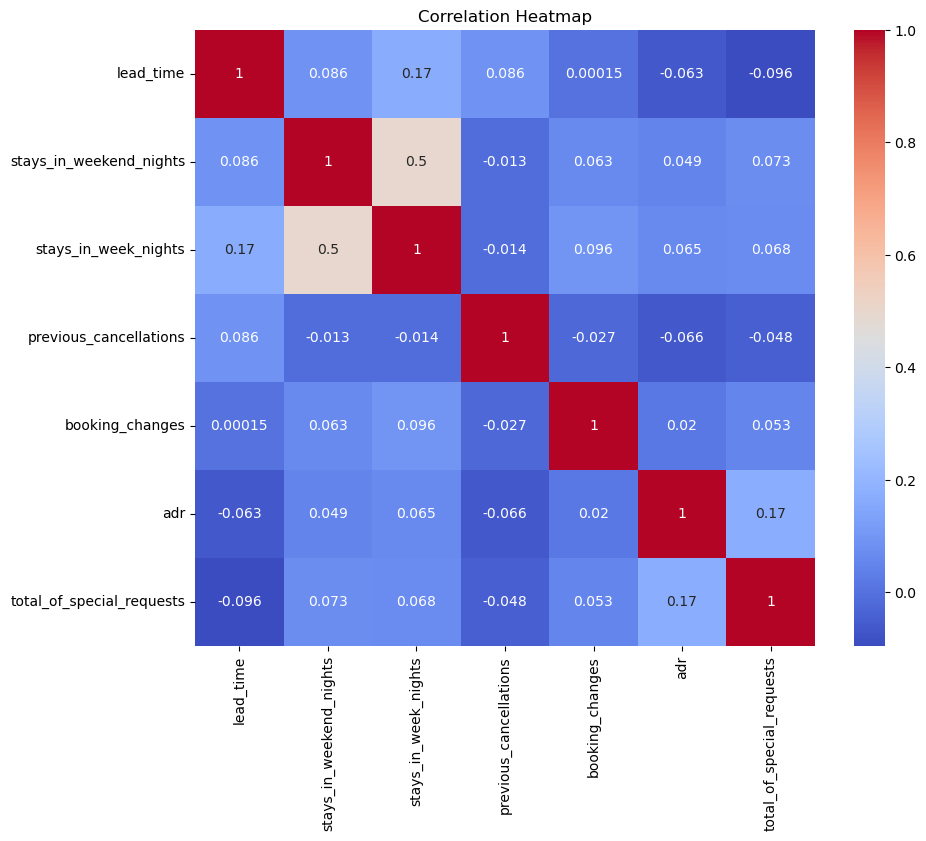

In [20]:
# calculate and visualise the correlation matrix to examine
# the relationships between numerical features. This helps
# identify highly correlated variables and provides insight
# into how different booking characteristics are related.
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows that most numerical features have weak correlations with one another. The strongest relationship is between stays_in_weekend_nights and stays_in_week_nights (0.50), while the remaining feature pairs have relatively low correlations. This suggests that the selected numerical features generally provide different information for the prediction models.

Distribution of hotel
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


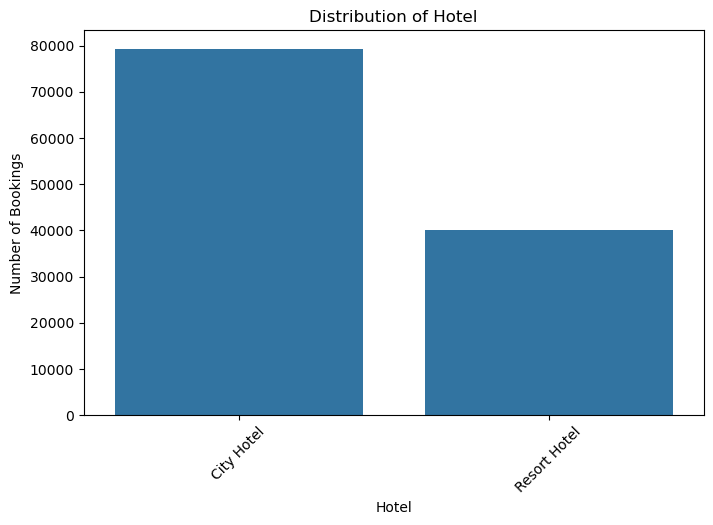

Distribution of meal
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


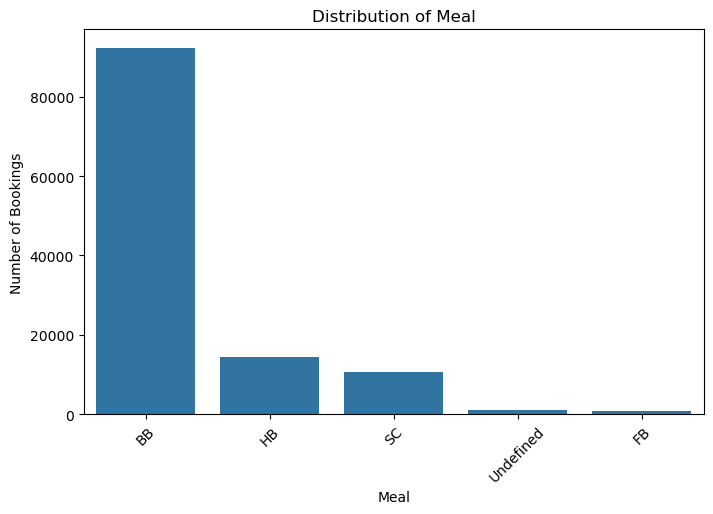

Distribution of market_segment
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


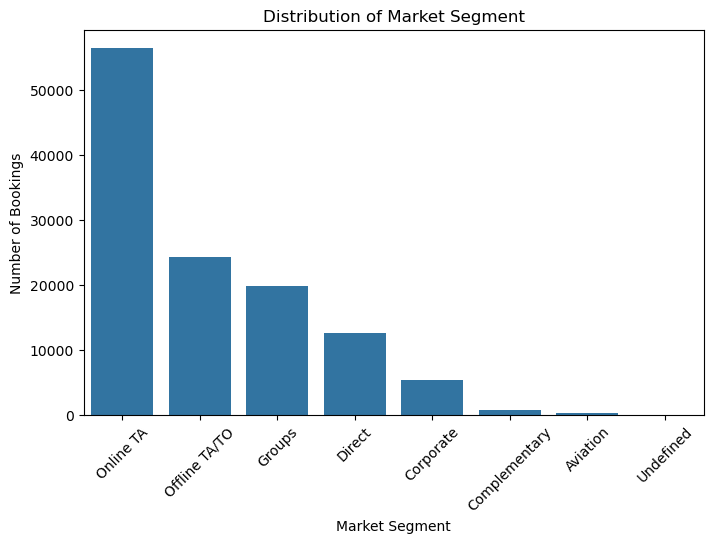

Distribution of distribution_channel
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64


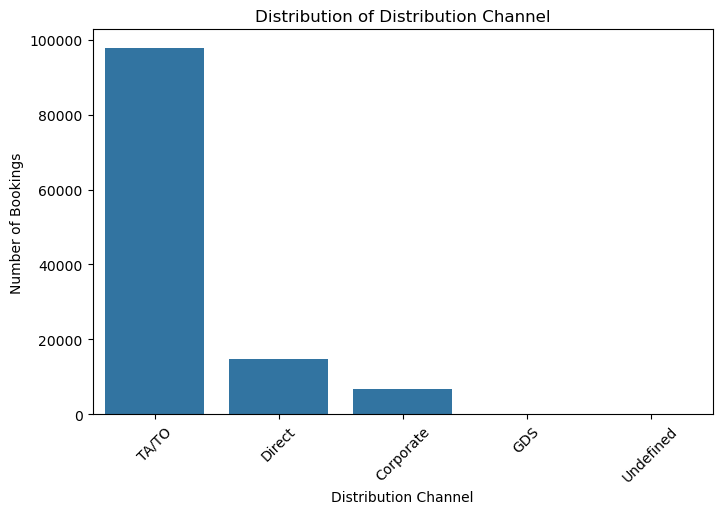

Distribution of reserved_room_type
reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64


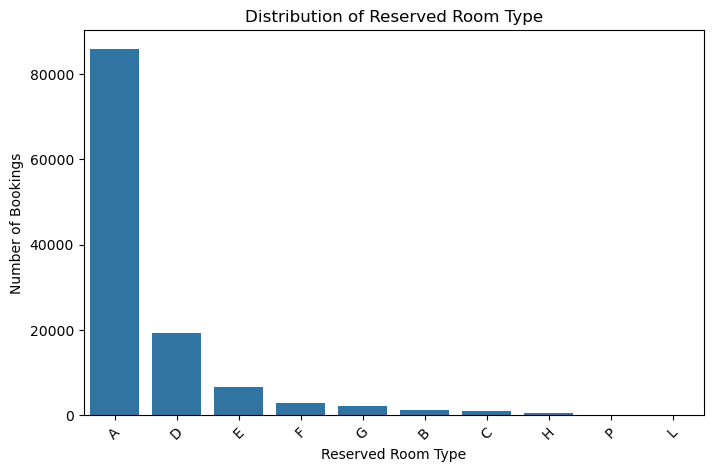

Distribution of deposit_type
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64


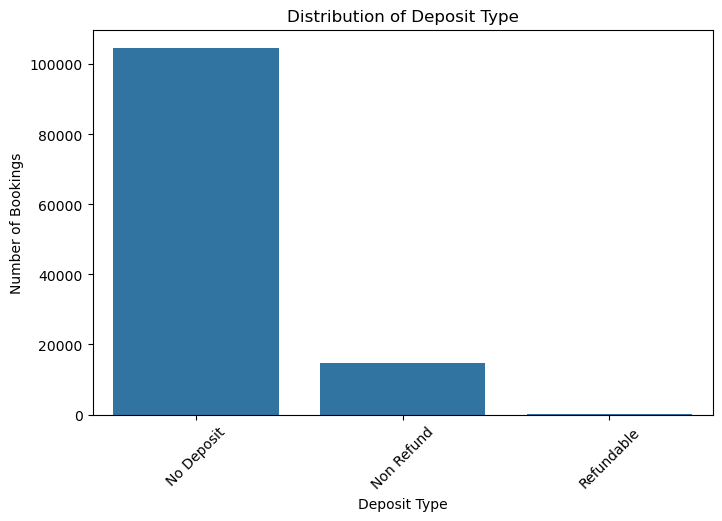

Distribution of customer_type
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


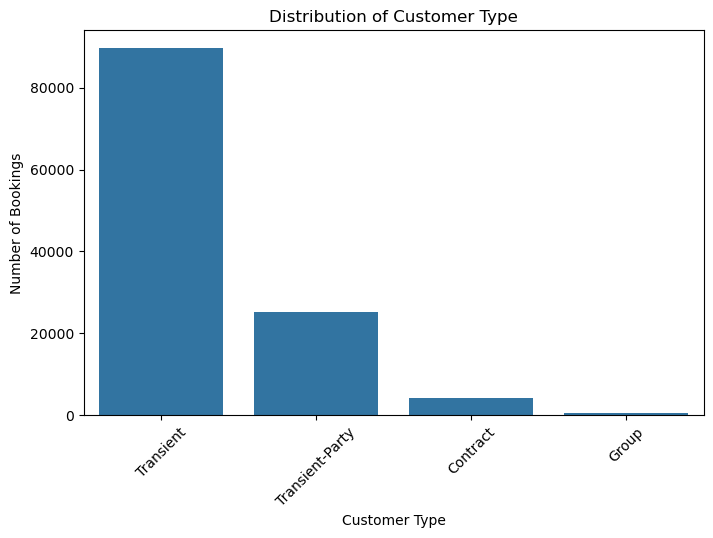

In [21]:
# select important categorical booking features 
# for analysisng the distribution of booking characteristics
categorical_features = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'deposit_type',
    'customer_type'
]

for column in categorical_features:

    #  frequency of each category
    print('Distribution of', column)
    print(df[column].value_counts())

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    # set chart title and axis labels
    plt.title(
        'Distribution of ' +
        column.replace('_', ' ').title()
    )

    plt.xlabel(
        column.replace('_', ' ').title()
    )

    plt.ylabel('Number of Bookings')

    plt.xticks(rotation=45)
    plt.show()

The categorical features are not evenly distributed, with a few categories accounting for most bookings. For example, City Hotels, BB meal plans, Online TA, TA/TO (Travel Agents/Tour Operators), Room Type A, No Deposit, and Transient customers are the most common categories. 

### 2.3.2 Understanding relationship between variables

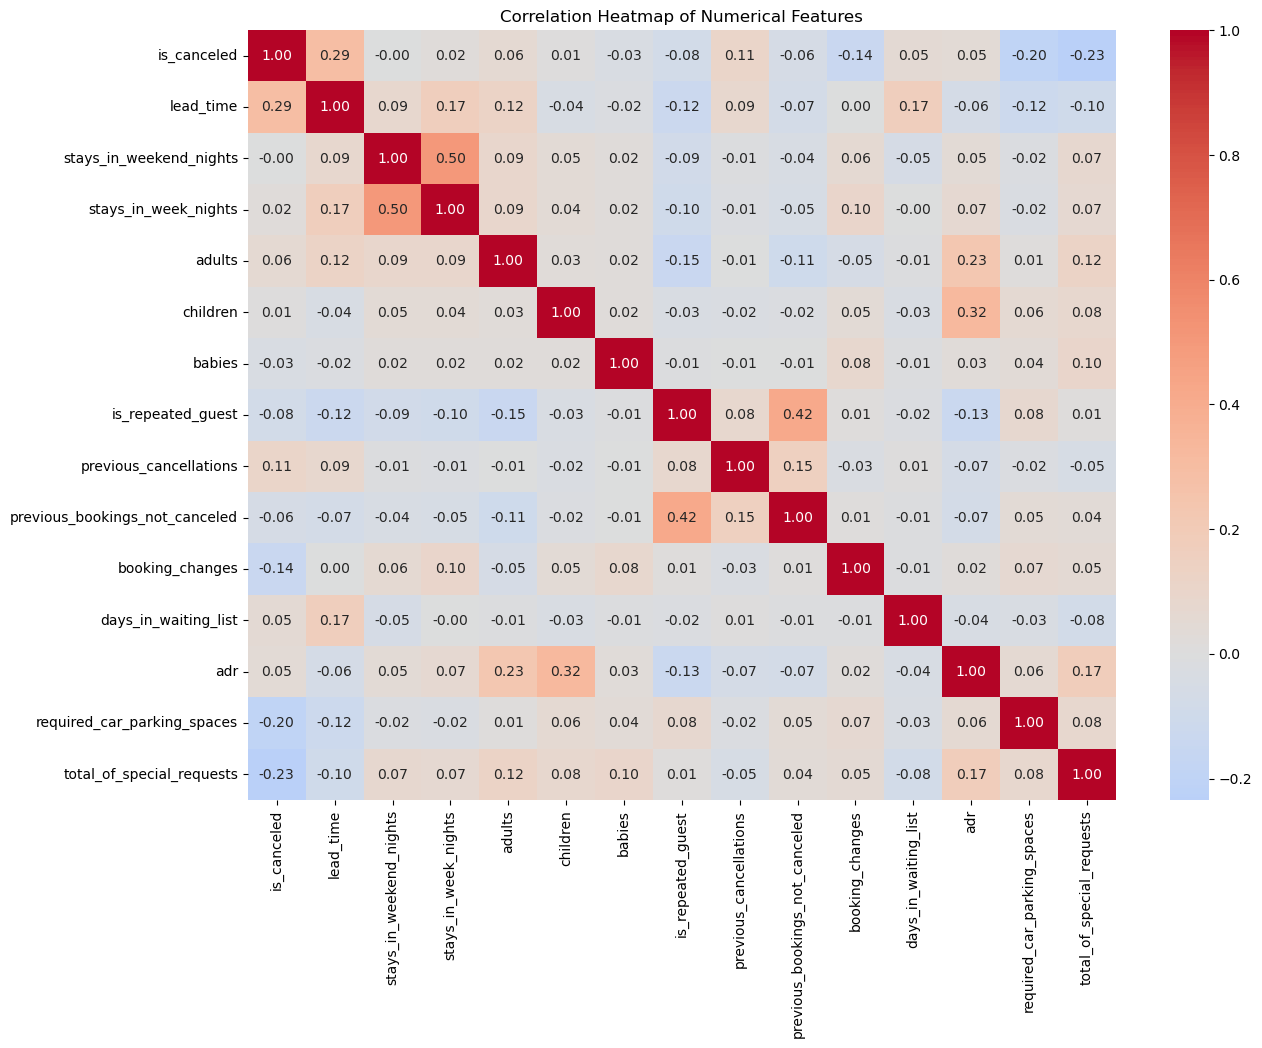

In [22]:
# select numerical features for correlation analysis
# to examine relationships between booking variables
correlation_features = [
    'is_canceled',
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

# calculate the correlation coefficients
correlation_matrix = df[correlation_features].corr()

# plot the correlation heatmap to visualise feature relationships
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

- Most numerical variables have weak correlations, indicating that they generally provide different information for predicting hotel booking cancellations.
- `lead_time` has the strongest positive correlation with `is_canceled` (0.29), suggesting that bookings made further in advance are more likely to be cancelled.
- `total_of_special_requests` (-0.23) and `required_car_parking_spaces` (-0.20) have the strongest negative correlations with `is_canceled`, indicating that these bookings are less likely to be cancelled.
- `stays_in_week_nights` and `stays_in_weekend_nights` have the strongest correlation (0.50), as both describe the duration of a guest's stay.

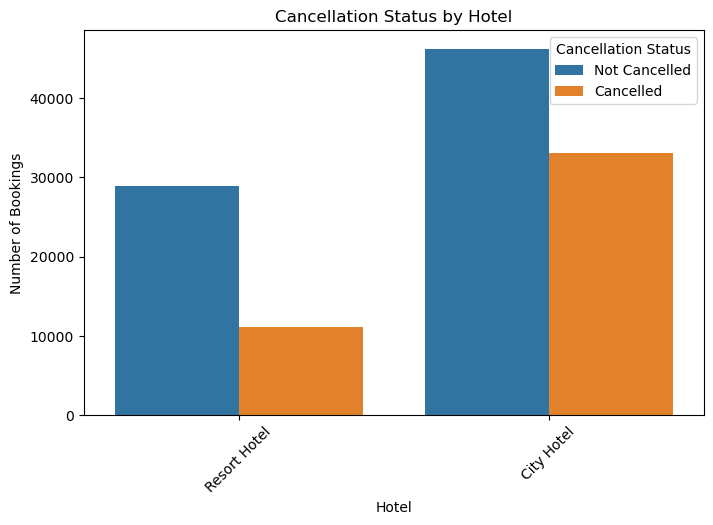

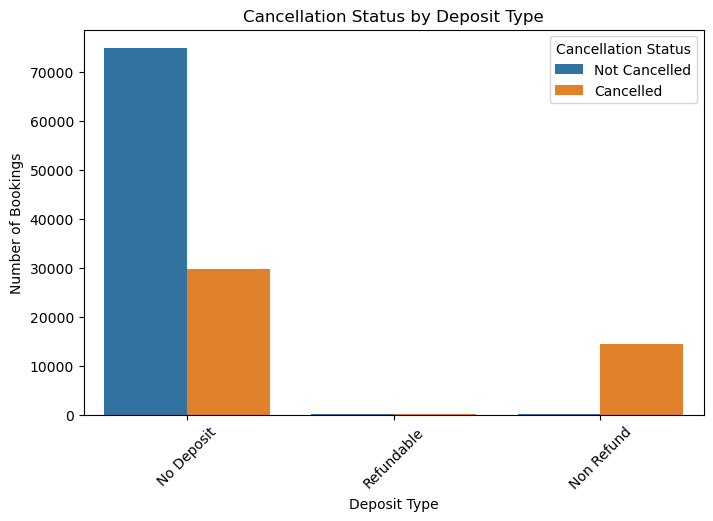

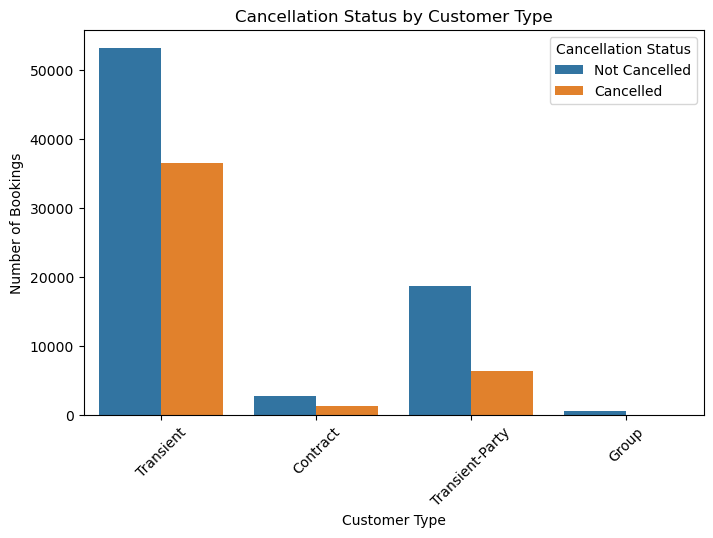

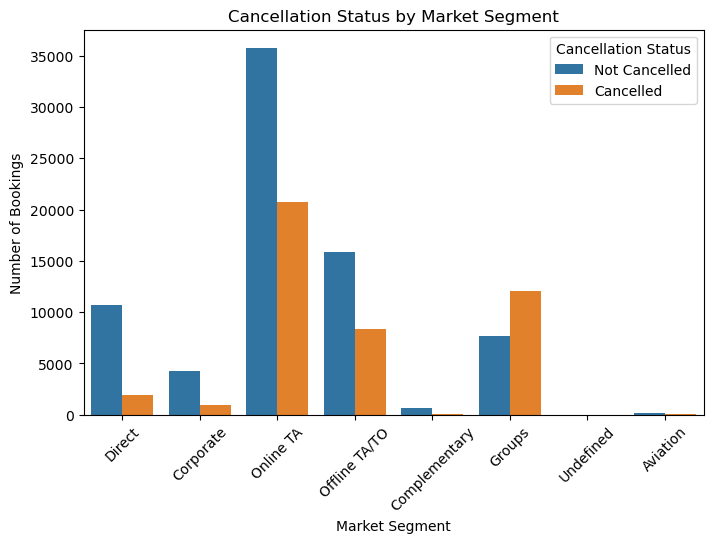

In [27]:
# select key categorical features for comparison
# to examine how booking characteristics relate to cancellations
categorical_features = [
    'hotel',
    'deposit_type',
    'customer_type',
    'market_segment'
]

# compare distribution of cancelled and non-cancelled bookings across each categorical feature
for column in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column,
        hue='is_canceled'
    )

    plt.title(f'Cancellation Status by {column.replace("_", " ").title()}')
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Number of Bookings')
    plt.xticks(rotation=45)
    plt.legend(title='Cancellation Status',
               labels=["Not Cancelled", "Cancelled"]
               )
    plt.show()

- **Transient** customers account for the highest number of bookings and cancellations, while **Group** bookings have the lowest.
- **Online TA** is the largest market segment, while **Groups** segment records relatively more cancelled than non-cancelled bookings.
- **City Hotels** have a higher number of cancellations than **Resort Hotels**, this is likely due to their larger booking volume.
- Bookings with **Non Refund** deposits show a very high proportion of cancellations, whereas **No Deposit** bookings are mostly not cancelled.

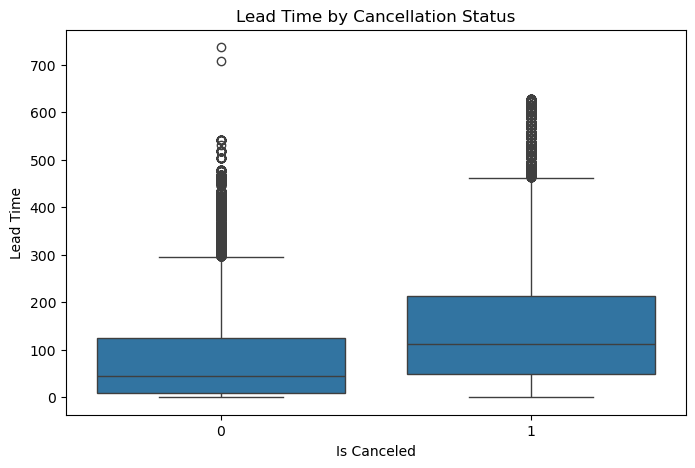

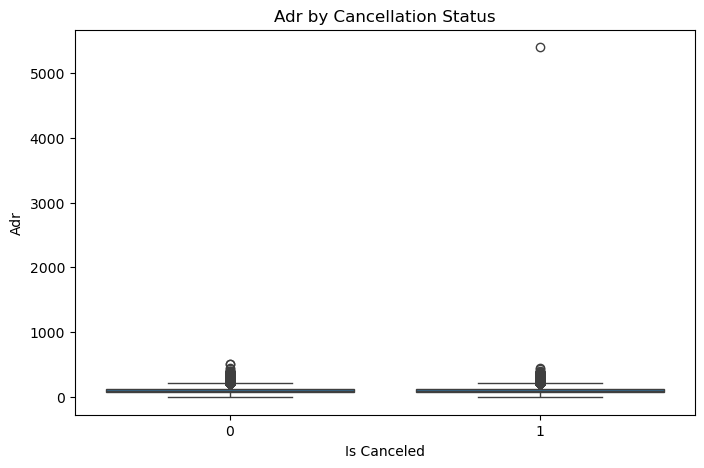

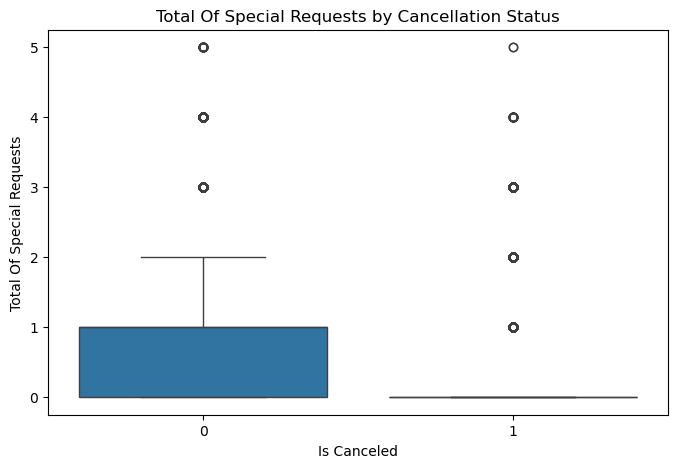

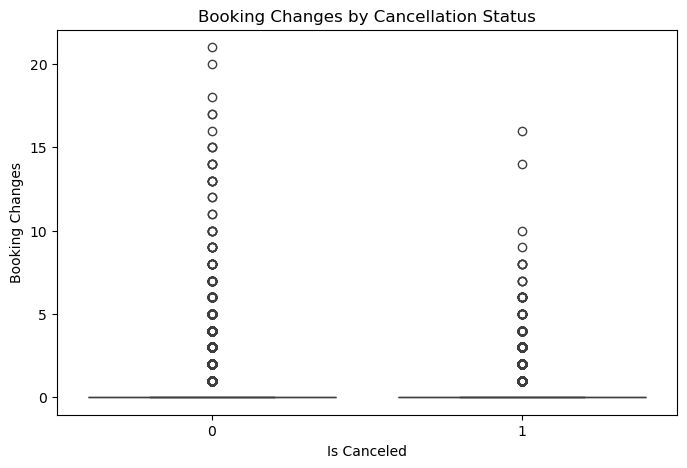

In [28]:
# select key numerical features for comparison
# to examine how their values differ between cancelled and non-cancelled bookings
numerical_features = [
    'lead_time',
    'adr',
    'total_of_special_requests',
    'booking_changes'
]

# compare the relationship between each numerical features and the two cancellation status
for column in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='is_canceled',
        y=column
    )

    plt.title(f'{column.replace("_", " ").title()} by Cancellation Status')
    plt.xlabel('Is Canceled')
    plt.ylabel(column.replace("_", " ").title())

    plt.show()

- Cancelled bookings generally have a higher **lead time** than non-cancelled bookings, suggesting that bookings made further in advance are more likely to be cancelled.
- The **ADR** distributions are relatively similar for both groups although cancelled bookings contain a few extreme outliers.
- Non-cancelled bookings generally have more **special requests**, this show that guests who make additional requests may be more committed to their bookings.
- Most bookings have **no booking changes**, regardless of cancellation status. However, non-cancelled bookings tend to have slightly more booking changes than cancelled bookings.

# 3. Data Preparation

## 3.1 Data Cleaning

In [29]:
# create copy of orignal dataset for data cleaning
df_clean = df.copy()
print("Dataset shape before cleaning:", df_clean.shape)

# check duplicate records
duplicates = df_clean.duplicated().sum()
print("Number of duplicate records:", duplicates)

# remove columns that may cause data leakage
# because these columns are only available after booking outcome
df_clean = df_clean.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ]
)

# remove redundant personal information, since they do not help predict booking cancellation
df_clean = df_clean.drop(
    columns=[
        "name",
        "email",
        "phone-number",
        "credit_card"
    ]
)

# remove the company column as it contains a large number of missing values
df_clean = df_clean.drop(columns=["company"])

# fill missing values in 'children' using the median
# to retain records for model training
df_clean["children"] = df_clean["children"].fillna(
    df_clean["children"].median()
)

# fill missing values in 'agent' with 0 (0 indicates that no travel agent was involved)
df_clean["agent"] = df_clean["agent"].fillna(0)

# fill missing values in 'country' using the most frequent country
df_clean["country"] = df_clean["country"].fillna(
    df_clean["country"].mode()[0]
)

# verify that all missing values have been handled successfully
print("Remaining missing values:")
print(df_clean.isnull().sum())

Dataset shape before cleaning: (119390, 36)
Number of duplicate records: 0
Remaining missing values:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0

- No duplicate records were found in the dataset.
- Missing values in the `children`, `agent`, and `country` columns were successfully handled using appropriate imputation methods.
- After data cleaning, the dataset contained no remaining missing values and was ready for model development.

## 3.2 Train-Test Split

In [32]:
# separate the features and target variable 
y = df_clean["is_canceled"]
X = df_clean.drop(columns=["is_canceled"])

# apply one hot encoding to categorical features
# so they can be used by machine learning models
X = pd.get_dummies(X, drop_first=True)


In [33]:
# split dataset into training and testing sets (70% for training, 30% for testing)
# to evaluate the model on unseen booking data
test_size = 0.3
random_state = 2026
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state)

# display size of training and testing dataset
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (83573, 246)
Testing Set: (35817, 246)


- The dataset was split into a training set (70%) and a testing set (30%).
- One-hot encoding was applied to convert categorical features into numerical format, this allows the machine learning models to process the data.


# 4. Modelling

### 4.2 Train Model

In [34]:
# create the Logistic Regression model
logr = LogisticRegression(random_state=2026, max_iter=5000)

# train the logr model
logr.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


c:\Users\yq\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The Logistic Regression model produced a convergence warning, indicating that the optimisation process did not fully converge within the maximum number of iterations. Despite this warning, the model completed training successfully and was included only as a baseline model for comparison. The final deployed model is the feature-selected Random Forest model, which achieved the best overall performance.

In [42]:
# create decision tree model
dt = DecisionTreeClassifier(
    random_state=2026
)

# train model using training dataset
dt.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [43]:
# create gradient boosting model
gbt = GradientBoostingClassifier(
    random_state=2026
)

# train model using training dataset
gbt.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [44]:
# create random forest model
rf = RandomForestClassifier(
    random_state=2026
)

# train model using training dataset
rf.fit(X_train, y_train)

print("Random Forest Model model trained successfully.")

Random Forest Model model trained successfully.


# 5. Model Evaluation

In [35]:
# generate predictions using the test dataset
logr_pred = logr.predict(X_test)

# calculate the evaluation metrics
# to measure the model's classification performance
logr_accuracy = accuracy_score(y_test, logr_pred)
logr_precision = precision_score(y_test, logr_pred, zero_division=0)
logr_recall = recall_score(y_test, logr_pred, zero_division=0)
logr_f1 = f1_score(y_test, logr_pred, zero_division=0)

# display the evaluation metrics
print("Logistic Regression")
print("Accuracy:", round(logr_accuracy, 4))
print("Precision:", round(logr_precision, 4))
print("Recall:", round(logr_recall, 4))
print("F1-Score:", round(logr_f1, 4))


Logistic Regression
Accuracy: 0.8122
Precision: 0.8074
Recall: 0.6457
F1-Score: 0.7176


The Logistic Regression model achieved an accuracy of **81.22%** with an F1-score of **71.76%**. While it provides a simple and interpretable baseline for comparison, its performance is lower than the tree-based models, particularly in recall. This indicates that Logistic Regression was less effective at identifying cancelled bookings. Therefore, more advanced models were evaluated to improve prediction performance.

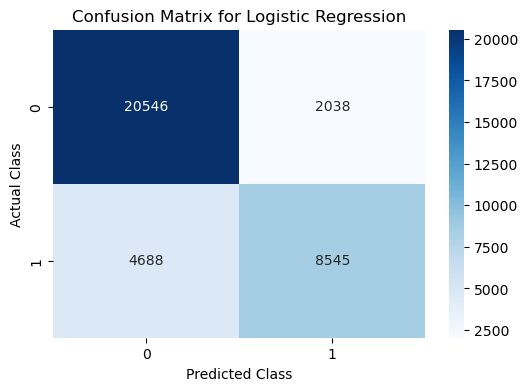

In [38]:
# create the confusion matrix
logr_cm = confusion_matrix(y_test, logr_pred)

# plot the confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    logr_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [39]:
# display the classification report
print(classification_report(y_test, logr_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22584
           1       0.81      0.65      0.72     13233

    accuracy                           0.81     35817
   macro avg       0.81      0.78      0.79     35817
weighted avg       0.81      0.81      0.81     35817



**Logistic Regression Evaluation Observation:**
- The Logistic Regression model achieved an **accuracy of 80.04%**, indicating that it correctly classified most hotel bookings.
- The model achieved a **precision of 78.85%** and a **recall of 62.82%**, showing that it predicts cancelled bookings reasonably well but misses some actual cancellations.
- The confusion matrix shows that most **non-cancelled bookings** were correctly classified (**20,354**), while **8,313** cancelled bookings were correctly identified. However, **4,920** cancelled bookings were incorrectly predicted as non-cancelled.
- Overall, Logistic Regression provides a good baseline model, although its relatively lower recall suggests that some cancelled bookings are not detected.

In [45]:
# generate predictions using the test dataset
dt_pred = dt.predict(X_test)

# calculate the evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)

# display the evaluation metrics
print("Decision Tree")
print("Accuracy:", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall:", round(dt_recall, 4))
print("F1-Score:", round(dt_f1, 4))

Decision Tree
Accuracy: 0.8593
Precision: 0.8063
Recall: 0.8149
F1-Score: 0.8106


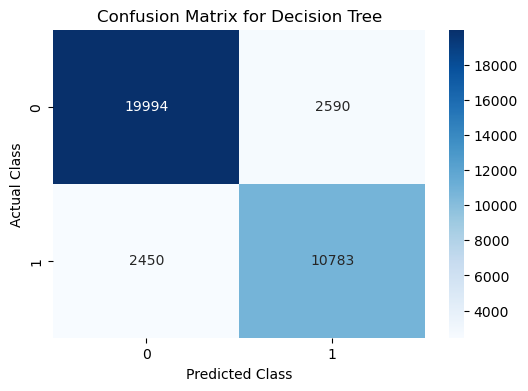

In [46]:
# create the confusion matrix
dt_cm = confusion_matrix(y_test, dt_pred)

# plot the confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [47]:
# display the classification report
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89     22584
           1       0.81      0.81      0.81     13233

    accuracy                           0.86     35817
   macro avg       0.85      0.85      0.85     35817
weighted avg       0.86      0.86      0.86     35817



**Decision Tree Evaluation Observation:**
- The Decision Tree model achieved an **accuracy of 85.93%**, outperforming the Logistic Regression model.
- The model achieved a **precision of 80.63%** and a **recall of 81.49%**, indicating a better balance in identifying cancelled bookings.
- The confusion matrix shows that **19,994** non-cancelled bookings and **10,783** cancelled bookings were correctly classified, with fewer cancelled bookings misclassified compared to Logistic Regression.
- Overall, the Decision Tree model demonstrates stronger classification performance and is a suitable model for predicting hotel booking cancellations.

In [48]:
# generate predictions using the test dataset
gbt_pred = gbt.predict(X_test)

# calculate the evaluation metrics
gbt_accuracy = accuracy_score(y_test, gbt_pred)
gbt_precision = precision_score(y_test, gbt_pred, zero_division=0)
gbt_recall = recall_score(y_test, gbt_pred, zero_division=0)
gbt_f1 = f1_score(y_test, gbt_pred, zero_division=0)

# display the evaluation metrics
print("Gradient Boosting")
print("Accuracy:", round(gbt_accuracy, 4))
print("Precision:", round(gbt_precision, 4))
print("Recall:", round(gbt_recall, 4))
print("F1-Score:", round(gbt_f1, 4))

Gradient Boosting
Accuracy: 0.8467
Precision: 0.8363
Recall: 0.7275
F1-Score: 0.7781


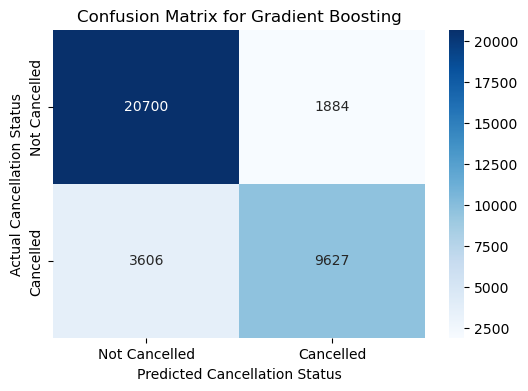

In [49]:
# create the confusion matrix
gbt_cm = confusion_matrix(y_test, gbt_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    gbt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"]
)

plt.title("Confusion Matrix for Gradient Boosting")
plt.xlabel("Predicted Cancellation Status")
plt.ylabel("Actual Cancellation Status")

plt.show()

In [50]:
# display the classification report
print(classification_report(y_test, gbt_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88     22584
           1       0.84      0.73      0.78     13233

    accuracy                           0.85     35817
   macro avg       0.84      0.82      0.83     35817
weighted avg       0.85      0.85      0.84     35817



**Gradient Boosting Model Evaluation Observation:**
- The Gradient Boosting model achieved an **accuracy of 84.67%**, performing better than Logistic Regression but slightly lower than the Decision Tree model.
- The model achieved a **precision of 83.63%** and a **recall of 72.75%**, indicating that it predicts cancelled bookings accurately but misses more actual cancellations than the Decision Tree model.
- The confusion matrix shows that **20,700** non-cancelled bookings and **9,627** cancelled bookings were correctly classified, while **3,606** cancelled bookings were incorrectly predicted as non-cancelled.
- Overall, the Gradient Boosting model demonstrates good predictive performance, although its lower recall makes it less effective at identifying all cancelled bookings.

In [51]:
# generate predictions using the test dataset
rf_pred = rf.predict(X_test)

# calculate the evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

# display the evaluation metrics
print("Random Forest")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-Score:", round(rf_f1, 4))

Random Forest
Accuracy: 0.8921
Precision: 0.8912
Recall: 0.8063
F1-Score: 0.8467


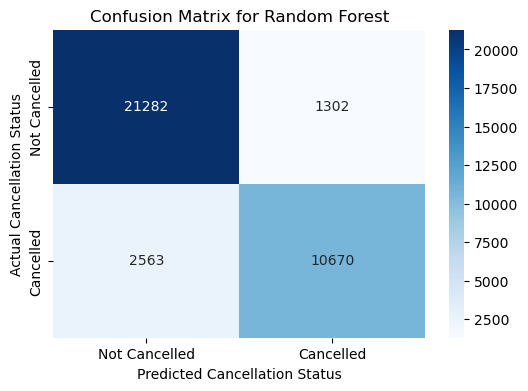

In [52]:
# create the confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)

# plot the confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"]
)

plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted Cancellation Status")
plt.ylabel("Actual Cancellation Status")

plt.show()

In [53]:
# display the classification report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     22584
           1       0.89      0.81      0.85     13233

    accuracy                           0.89     35817
   macro avg       0.89      0.87      0.88     35817
weighted avg       0.89      0.89      0.89     35817



**Random Forest Model Observation:**
- The Random Forest model achieved the highest **accuracy of 89.21%** among the models evaluated so far.
- The model achieved a **precision of 89.12%** and a **recall of 80.63%**, indicating strong performance in identifying both cancelled and non-cancelled bookings.
- The confusion matrix shows that **21,282** non-cancelled bookings and **10,670** cancelled bookings were correctly classified, with fewer misclassifications compared to the other models.
- Overall, the Random Forest model demonstrates the best overall performance and is selected as the most suitable model for predicting hotel booking cancellations.

In [54]:
# store the evaluation results for all models
evaluation_results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": logr_accuracy,
        "Precision": logr_precision,
        "Recall": logr_recall,
        "F1-Score": logr_f1
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1-Score": dt_f1
    },
        {
        "Model": "Gradient Boosting",
        "Accuracy": gbt_accuracy,
        "Precision": gbt_precision,
        "Recall": gbt_recall,
        "F1-Score": gbt_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1-Score": rf_f1
    }
]

results_df = pd.DataFrame(evaluation_results)

# results rounded to 4 decimal places
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8122,0.8074,0.6457,0.7176
1,Decision Tree,0.8593,0.8063,0.8149,0.8106
2,Gradient Boosting,0.8467,0.8363,0.7275,0.7781
3,Random Forest,0.8921,0.8912,0.8063,0.8467


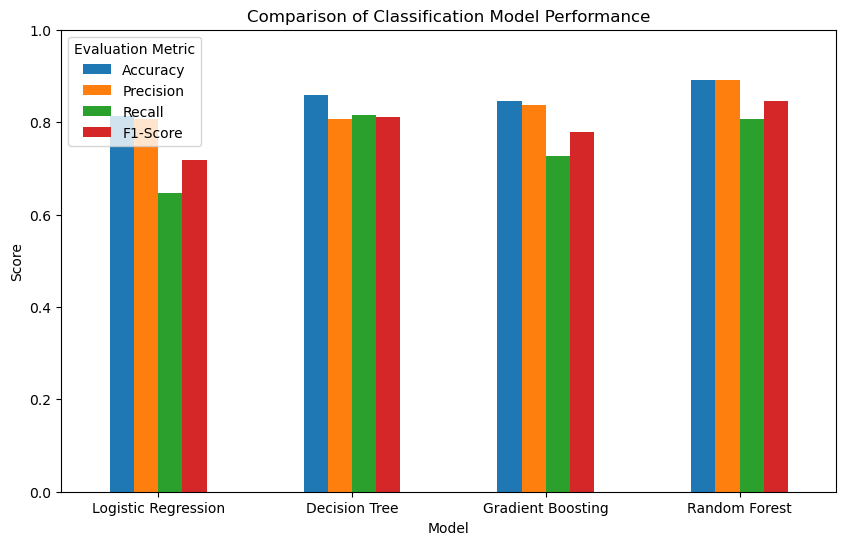

In [55]:
# plot the model evaluation results
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.show()

- The **Random Forest** model achieved the highest **accuracy (89.21%)**, **precision (89.12%)**, and **F1-score (84.67%)**, this indicates that it has the best overall classification performance among the four models.
- Although the **Decision Tree** model achieved the highest **recall (81.49%)**, its overall performance was lower than Random Forest based on the other evaluation metrics.
- The **Logistic Regression** model recorded the lowest performance across most metrics, while **Gradient Boosting** showed better results than Logistic Regression but did not outperform Random Forest.
- Based on the evaluation results, the **Random Forest model** was selected for further improvement because it provides the best balance between correctly identifying cancelled bookings and minimising incorrect predictions.

### Evaluation Metric Justification

Accuracy was used to measure the overall proportion of hotel bookings classified correctly. However, recall and F1-score were also considered because failing to identify a booking that will be cancelled may prevent the hotel from reselling the room or adjusting its inventory.

F1-score provides a balance between precision and recall. This is useful because the hotel needs to identify likely cancellations while avoiding too many incorrect cancellation alerts. Therefore, accuracy was used for overall comparison, while recall and F1-score were used to assess performance on cancelled bookings.

In [56]:
# select a fixed unseen booking from the test dataset
booking_index = X_test_selected.index[0]

new_booking = X_test_selected.loc[
    [booking_index]
]

# display the selected booking
new_booking

NameError: name 'X_test_selected' is not defined

In [137]:
# use the final model
# the final feature-selected Random Forest model is selected after iterative model development.
final_model = rf_selected

# generate the predicted class
prediction = final_model.predict(
    new_booking
)[0]

# generate the probability of cancellation
cancellation_probability = final_model.predict_proba(
    new_booking
)[0][1]

In [37]:
# convert the predicted class into a readable label
if prediction == 1:
    prediction_label = "Cancelled"
else:
    prediction_label = "Not Cancelled"

print(
    "Predicted Booking Status:",
    prediction_label
)

print(
    "Cancellation Probability:",
    f"{cancellation_probability:.2%}"
)

NameError: name 'prediction' is not defined

In [141]:
# retrieve the actual outcome of the selected test booking
actual_outcome = y_test.loc[
    booking_index
]

if actual_outcome == 1:
    actual_label = "Cancelled"
else:
    actual_label = "Not Cancelled"

print(
    "Actual Booking Status:",
    actual_label
)

Actual Booking Status: Cancelled


In [142]:
# compare the predicted and actual booking outcomes
if prediction == actual_outcome:
    print("Prediction Result: Correct")
else:
    print("Prediction Result: Incorrect")

Prediction Result: Incorrect


### Prediction Interpretation

The final Random Forest model predicted the unseen booking as **Not Cancelled**, with a cancellation probability of **38.00%**. Since the probability was below the default classification threshold of 50%, the booking was classified as not cancelled.

However, the actual booking outcome was **Cancelled**, meaning that this booking was incorrectly classified. This shows that although the model achieved an overall accuracy of **89.28%**, it may still make errors when predicting individual unseen bookings. Such errors are also reflected in the confusion matrix and recall score presented earlier.

## Iterative model development


## Feature Importance

Feature importance was calculated using the baseline Random Forest model to identify which encoded features contributed most to the prediction of hotel booking cancellations. The results were then used to perform feature selection in the next stage.

In [57]:
# calculate the importance score of each feature
# to identify the most influential predictors
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,lead_time,0.116266
241,deposit_type_Non Refund,0.078842
15,adr,0.070578
168,country_PRT,0.066750
17,total_of_special_requests,0.058424
3,arrival_date_day_of_month,0.051209
2,arrival_date_week_number,0.046087
13,agent,0.042867
5,stays_in_week_nights,0.036933
10,previous_cancellations,0.028379


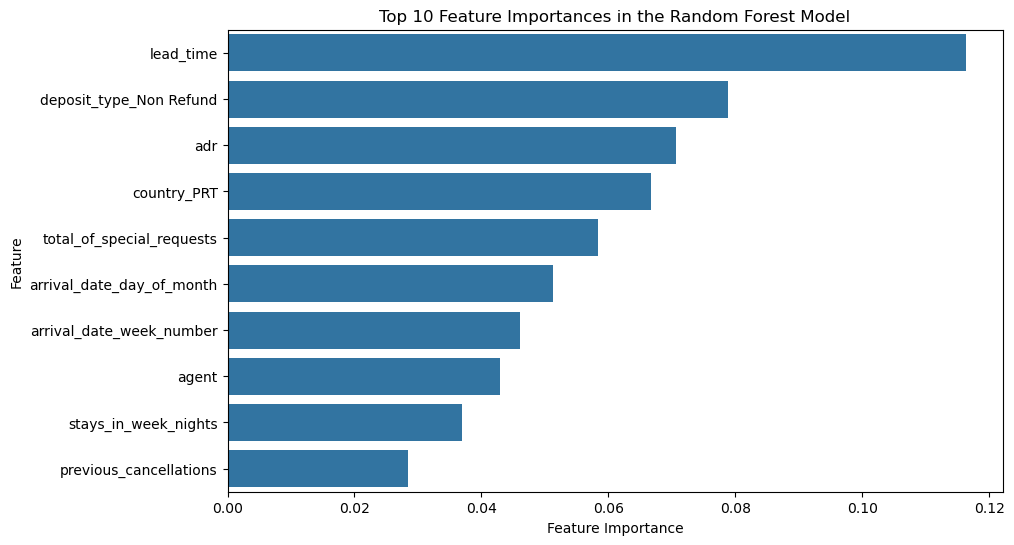

In [58]:
# plot the top 10 most important features
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances in the Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

**Feature Importance Observation:**
- The feature importance plot shows that **lead_time** is the most important feature in predicting hotel booking cancellations, followed by **deposit_type_Non Refund** and **adr**.
- Other important features include **country_PRT**, **total_of_special_requests**, and **previous_cancellations**, indicating that customer behaviour and booking characteristics play an important role in predicting cancellations.
- These findings provide insight into the factors that contribute most to the Random Forest model and will be used to guide further model improvement.

In [59]:
# calculate the cumulative feature importance
# to determine how much each feature contributes overall
feature_importance["Cumulative Importance"] = (
    feature_importance["Importance"].cumsum()
)

# select features that contribute to the first 95% of cumulative importance
selected_features = feature_importance.loc[
    feature_importance["Cumulative Importance"] <= 0.95,
    "Feature"
].tolist()

# include the next feature that crosses the 95% threshold to ensure sufficient coverage
if len(selected_features) < len(feature_importance):
    next_feature = feature_importance.iloc[len(selected_features)]["Feature"]
    selected_features.append(next_feature)

# display the number of selected features
print("Original number of features:", X_train.shape[1])
print("Number of selected features:", len(selected_features))

# display the selected features
selected_features

Original number of features: 246
Number of selected features: 54


['lead_time',
 'deposit_type_Non Refund',
 'adr',
 'country_PRT',
 'total_of_special_requests',
 'arrival_date_day_of_month',
 'arrival_date_week_number',
 'agent',
 'stays_in_week_nights',
 'previous_cancellations',
 'stays_in_weekend_nights',
 'arrival_date_year',
 'booking_changes',
 'required_car_parking_spaces',
 'customer_type_Transient',
 'market_segment_Online TA',
 'market_segment_Groups',
 'customer_type_Transient-Party',
 'adults',
 'distribution_channel_TA/TO',
 'assigned_room_type_D',
 'market_segment_Offline TA/TO',
 'hotel_Resort Hotel',
 'country_GBR',
 'country_DEU',
 'country_FRA',
 'reserved_room_type_D',
 'market_segment_Direct',
 'meal_HB',
 'children',
 'meal_SC',
 'arrival_date_month_August',
 'country_ESP',
 'arrival_date_month_July',
 'distribution_channel_Direct',
 'arrival_date_month_May',
 'previous_bookings_not_canceled',
 'arrival_date_month_June',
 'arrival_date_month_October',
 'assigned_room_type_E',
 'arrival_date_month_March',
 'arrival_date_month_Sep

Feature selection was performed using the cumulative feature importance scores obtained from the baseline Random Forest model. Features contributing to the first **95% of the cumulative importance** were retained, resulting in a reduction from **246 encoded features to 54 selected features**.

Reducing the number of features helps simplify the model by removing less informative variables while retaining the features that contribute most to the prediction. This may reduce computational complexity, improve model interpretability and minimise unnecessary noise without significantly affecting predictive performance.

The selected features were used to train a new Random Forest model in the next stage to evaluate whether feature selection improved the model's performance.

In [61]:
# create new training and testing sets using only
# the selected features identified from feature importance
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# display the shape of the reduced datasets
# to confirm that the number of features has decreased
print("Selected training set:", X_train_selected.shape)
print("Selected testing set:", X_test_selected.shape)

Selected training set: (83573, 54)
Selected testing set: (35817, 54)


In [62]:
from sklearn.base import clone

# create a copy of the baseline Random Forest model
# so the same settings can be used for a fair comparison
rf_selected = clone(rf)

# train the model using only the selected features
rf_selected.fit(X_train_selected, y_train)

# generate predictions using the selected features
rf_selected_pred = rf_selected.predict(X_test_selected)

In [63]:
# calculate evaluation metrics
# to compare the feature-selected model with the baseline
rf_selected_accuracy = accuracy_score(y_test, rf_selected_pred)
rf_selected_precision = precision_score(
    y_test,
    rf_selected_pred,
    zero_division=0
)
rf_selected_recall = recall_score(
    y_test,
    rf_selected_pred,
    zero_division=0
)
rf_selected_f1 = f1_score(
    y_test,
    rf_selected_pred,
    zero_division=0
)

# display the evaluation metrics
print("Random Forest with Feature Selection")
print("Accuracy:", round(rf_selected_accuracy, 4))
print("Precision:", round(rf_selected_precision, 4))
print("Recall:", round(rf_selected_recall, 4))
print("F1-Score:", round(rf_selected_f1, 4))

Random Forest with Feature Selection
Accuracy: 0.8928
Precision: 0.882
Recall: 0.8193
F1-Score: 0.8495


In [66]:
# compare the baseline and feature-selected Random Forest models
feature_selection_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Random Forest with Feature Selection"
    ],
    "Number of Features": [
        X_train.shape[1],
        len(selected_features)
    ],
    "Accuracy": [
        rf_accuracy,
        rf_selected_accuracy
    ],
    "Precision": [
        rf_precision,
        rf_selected_precision
    ],
    "Recall": [
        rf_recall,
        rf_selected_recall
    ],
    "F1-Score": [
        rf_f1,
        rf_selected_f1
    ]
})

feature_selection_comparison.round(4)

,Model,Number of Features,Accuracy,Precision,Recall,F1-Score
0,Baseline Random Forest,246,0.8921,0.8912,0.8063,0.8467
1,Random Forest with Feature Selection,54,0.8928,0.8820,0.8193,0.8495


### Feature Selection Observation
- Feature selection reduced the number of features from **246 to 54**, representing a reduction of approximately **78%**, resulting in a simpler and more efficient model.
- The feature-selected Random Forest achieved a slightly higher **accuracy (89.28%)**, **recall (81.93%)** and **F1-score (84.95%)** than the baseline model, while using substantially fewer features.
- Although precision decreased slightly (89.12% → 88.20%), the improvement in recall and F1-score suggests that the model became better at identifying cancelled bookings while maintaining strong overall predictive performance.
- Reducing the number of features also lowers model complexity, improves computational efficiency and makes the model easier to interpret without sacrificing predictive performance.
- Therefore, the feature-selected Random Forest model was selected for hyperparameter tuning in the next stage.

In [64]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

# create a reproducible cross-validation strategy
# to evaluate model performance consistently
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2026
)

In [65]:
# evaluate the feature-selected Random Forest
# using five-fold cross-validation before hyperparameter tuning
baseline_cv_scores = cross_val_score(
    estimator=rf_selected,
    X=X_train_selected,
    y=y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

# calculate the average cross-validation accuracy
baseline_cv_accuracy = baseline_cv_scores.mean()

print("Cross-Validation Accuracy for Each Fold:")
print(baseline_cv_scores.round(4))

print(
    "\nMean Baseline Cross-Validation Accuracy:",
    round(baseline_cv_accuracy, 4)
)

Cross-Validation Accuracy for Each Fold:
[0.8882 0.8903 0.8898 0.8863 0.8867]

Mean Baseline Cross-Validation Accuracy: 0.8883


### Cross-Validation Observation
- Five-fold cross-validation was performed to evaluate how consistently the feature-selected Random Forest model performed on different subsets of the training data.
- The cross-validation accuracies ranged from **88.63% to 89.03%**, with a mean accuracy of **88.83%**.
- The small variation between the five folds indicates that the model generalises well and produces stable performance across different training and validation splits.
- Therefore, the feature-selected Random Forest provides a reliable baseline for comparison after hyperparameter tuning.

In [67]:
# define the hyperparameter values
# to evaluate different Random Forest configurations
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [68]:
# search for the best Random Forest hyperparameter combination
# using Randomized Search with five-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=rf_selected,
    param_distributions=param_grid,
    n_iter=10,
    scoring="accuracy",
    cv=cv_strategy,
    random_state=2026,
    n_jobs=-1,
    return_train_score=True
)

# train and evaluate the sampled parameter combinations using the training dataset
random_search.fit(
    X_train_selected,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...om_state=2026)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

### Best Hyperparameters

RandomizedSearchCV selected the following Random Forest settings:

- `n_estimators = 200`
- `max_depth = None`
- `min_samples_split = 5`
- `min_samples_leaf = 1`

Compared with the feature-selected baseline model, the tuned model increased the number of trees from **100 to 200** and increased `min_samples_split` from **2 to 5**. The other two tuned hyperparameters remained at their default values.

Using 200 trees may improve the stability of the ensemble, while increasing `min_samples_split` makes each tree slightly more restricted and may reduce overfitting. However, the tuned settings still need to be evaluated on the unseen test dataset before deciding whether they should be used as the final model.

In [69]:
# display best hyperparameter combination
# selected using cross-validation
print("Best Hyperparameters:")
print(random_search.best_params_)

# display the best mean validation accuracy
print(
    "\nBest Cross-Validation Accuracy:",
    round(random_search.best_score_, 4)
)

Best Hyperparameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}

Best Cross-Validation Accuracy: 0.8885


In [70]:
# convert the cross-validation results into a DataFrame
# for easier analysis and comparison
tuning_results = pd.DataFrame(
    random_search.cv_results_
)

# select the key evaluation metrics
# for comparing each hyperparameter combination
tuning_log = tuning_results[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# sort the hyperparameter combinations
# from best to worst validation performance
tuning_log = tuning_log.sort_values(
    by="rank_test_score"
)

# rename logs for better readability
tuning_log.columns = [
    "Number of Trees",
    "Maximum Depth",
    "Minimum Samples Split",
    "Minimum Samples Leaf",
    "Mean Training Accuracy",
    "Mean Validation Accuracy",
    "Validation Standard Deviation",
    "Validation Rank"
]

tuning_log.round(4)

,Number of Trees,Maximum Depth,Minimum Samples Split,Minimum Samples Leaf,Mean Training Accuracy,Mean Validation Accuracy,Validation Standard Deviation,Validation Rank
0,200,None,5,1,0.9836,0.8885,0.0021,1
7,100,None,10,1,0.9556,0.8852,0.0024,2
4,200,None,2,4,0.9235,0.8806,0.0022,3
1,100,None,2,4,0.9231,0.8805,0.0026,4
3,300,20,5,1,0.9212,0.8798,0.0014,5
6,100,20,10,2,0.9050,0.8762,0.0023,6
9,200,10,10,2,0.8524,0.8495,0.0024,7
8,100,10,5,4,0.8525,0.8493,0.0022,8
5,200,10,2,2,0.8524,0.8492,0.0025,9
2,300,10,10,1,0.8526,0.8488,0.0018,10


### Hyperparameter Tuning Observation

Four Random Forest hyperparameters (**n_estimators**, **max_depth**, **min_samples_split** and **min_samples_leaf**) were tuned using RandomizedSearchCV with five-fold cross-validation. The best-performing hyperparameter combination achieved a mean cross-validation accuracy of **0.8885** using **200 trees**, **no maximum depth**, **min_samples_split = 5** and **min_samples_leaf = 1**.

The differences in validation accuracy between the tested parameter combinations were relatively small, indicating that the Random Forest model was stable across different hyperparameter settings. Although this combination achieved the highest cross-validation accuracy, the **feature-selected Random Forest** achieved slightly better performance on the unseen test dataset, particularly in terms of **accuracy** and **F1-score**. Therefore, the feature-selected Random Forest was retained as the final deployment model.

In [72]:
# compare cross-validation performance before and after tuning
cv_comparison = pd.DataFrame({
    "Model": [
        "Feature-Selected Random Forest",
        "Tuned Random Forest"
    ],
    "Mean Cross-Validation Accuracy": [
        baseline_cv_accuracy,
        random_search.best_score_
    ]
})

# calculate the difference from the baseline model
cv_comparison["Difference from Selected Model"] = (
    cv_comparison["Mean Cross-Validation Accuracy"]
    - baseline_cv_accuracy
)

cv_comparison.round(4)

,Model,Mean Cross-Validation Accuracy,Difference from Selected Model
0,Feature-Selected Random Forest,0.8883,0.0000
1,Tuned Random Forest,0.8885,0.0002


### Cross-Validation Comparison Observation

- Hyperparameter tuning produced a slight increase in the mean cross-validation accuracy, improving from **88.83%** to **88.85%**.
- The improvement of **0.02 percentage points** was very small, indicating that hyperparameter tuning had only a limited effect on the model's cross-validation performance.
- When evaluated on the unseen test dataset, the tuned model achieved slightly lower accuracy and F1-score than the feature-selected Random Forest.
- Therefore, the feature-selected Random Forest was selected as the final model because it demonstrated better generalisation to unseen booking data while using the same reduced feature set.

In [74]:
# retrieve the best-performing Random Forest model
# identified through hyperparameter tuning
tuned_rf = random_search.best_estimator_

# generate predictions using the unseen test data
tuned_rf_pred = tuned_rf.predict(
    X_test_selected
)

In [75]:
# evaluate the feature-selected Random Forest on the test set
rf_selected_accuracy = accuracy_score(
    y_test,
    rf_selected_pred
)

rf_selected_precision = precision_score(
    y_test,
    rf_selected_pred,
    zero_division=0
)

rf_selected_recall = recall_score(
    y_test,
    rf_selected_pred,
    zero_division=0
)

rf_selected_f1 = f1_score(
    y_test,
    rf_selected_pred,
    zero_division=0
)

In [76]:
# calculate the evaluation metrics for the tuned Random Forest model
tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

# display the tuned model performance
print("Tuned Random Forest")
print("Accuracy:", round(tuned_rf_accuracy, 4))
print("Precision:", round(tuned_rf_precision, 4))
print("Recall:", round(tuned_rf_recall, 4))
print("F1-Score:", round(tuned_rf_f1, 4))

Tuned Random Forest
Accuracy: 0.8913
Precision: 0.8831
Recall: 0.8134
F1-Score: 0.8468


### Tuned Random Forest Observation

The tuned Random Forest achieved an **accuracy of 89.13%**, **precision of 88.31%**, **recall of 81.34%** and **F1-score of 84.68%** on the unseen test dataset.

Compared with the feature-selected Random Forest, the tuned model achieved a slightly higher precision but slightly lower accuracy, recall and F1-score. The differences were minimal, indicating that hyperparameter tuning did not provide a meaningful improvement in predictive performance.

Therefore, the feature-selected Random Forest was retained as the final model because it achieved the best overall balance of accuracy, recall and F1-score while using the same reduced feature set of 54 features.

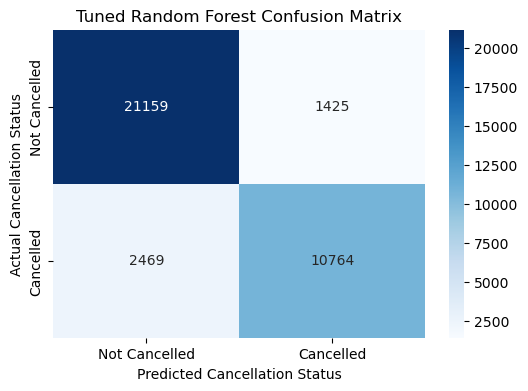

In [77]:
# generate the confusion matrix to evaluate
# the prediction outcomes on the test dataset
tuned_rf_cm = confusion_matrix(
    y_test,
    tuned_rf_pred
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    tuned_rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Cancelled",
        "Cancelled"
    ],
    yticklabels=[
        "Not Cancelled",
        "Cancelled"
    ]
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Cancellation Status")
plt.ylabel("Actual Cancellation Status")

plt.show()

### Confusion Matrix Observation
The confusion matrix shows that the tuned Random Forest correctly classified **21,159** bookings that were **not cancelled** and **10,764** bookings that were **cancelled**.

Only **1,425** bookings were incorrectly predicted as cancelled (false positives), while **2,469** cancelled bookings were incorrectly predicted as not cancelled (false negatives).

Overall, the relatively high number of correct predictions and comparatively low number of misclassifications indicate that the model is effective at distinguishing between cancelled and non-cancelled hotel bookings.

In [78]:
# display the detailed classification metrics for each booking cancellation class
print(
    classification_report(
        y_test,
        tuned_rf_pred,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Not Cancelled       0.90      0.94      0.92     22584
    Cancelled       0.88      0.81      0.85     13233

     accuracy                           0.89     35817
    macro avg       0.89      0.88      0.88     35817
 weighted avg       0.89      0.89      0.89     35817



### Classification Report Observation
The tuned Random Forest achieved an overall **accuracy of 89%** on the unseen test dataset.

For **Not Cancelled** bookings, the model achieved a **precision of 90%**, **recall of 94%** and **F1-score of 92%**, indicating excellent performance in identifying bookings that were likely to proceed.

For **Cancelled** bookings, the model achieved a **precision of 88%**, **recall of 81%** and **F1-score of 85%**. Although the recall was slightly lower, the model was still able to correctly identify the majority of cancelled bookings while maintaining strong overall predictive performance.

These results demonstrate that the Random Forest model generalises well to unseen booking data and is suitable for predicting hotel booking cancellations.

In [81]:
# compare the performance of the Random Forest versions
rf_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Random Forest with Feature Selection",
        "Tuned Random Forest"
    ],
    "Features": [
        X_train.shape[1],
        X_train_selected.shape[1],
        X_train_selected.shape[1]
    ],
    "Accuracy": [
        rf_accuracy,
        rf_selected_accuracy,
        tuned_rf_accuracy
    ],
    "Precision": [
        rf_precision,
        rf_selected_precision,
        tuned_rf_precision
    ],
    "Recall": [
        rf_recall,
        rf_selected_recall,
        tuned_rf_recall
    ],
    "F1-Score": [
        rf_f1,
        rf_selected_f1,
        tuned_rf_f1
    ]
})

rf_comparison.round(4)

,Model,Features,Accuracy,Precision,Recall,F1-Score
0,Baseline Random Forest,246,0.8921,0.8912,0.8063,0.8467
1,Random Forest with Feature Selection,54,0.8928,0.8820,0.8193,0.8495
2,Tuned Random Forest,54,0.8913,0.8831,0.8134,0.8468


### Final Random Forest Comparison Observation
The three Random Forest models achieved very similar predictive performance. The baseline Random Forest achieved an accuracy of **89.21%** using **246 features**.

After applying feature selection, the number of features was reduced from **246 to 54** (approximately **78% fewer features**). Despite this substantial reduction, the feature-selected Random Forest achieved the **highest accuracy (89.28%)**, **highest recall (81.93%)** and **highest F1-score (84.95%)**, demonstrating that the most informative features were retained while less important features were removed.

Although hyperparameter tuning slightly improved the model's precision (**88.31%**), it resulted in slightly lower accuracy, recall and F1-score than the feature-selected model. The performance differences were very small, indicating that hyperparameter tuning did not provide a meaningful improvement.

Therefore, the **Random Forest with Feature Selection** was selected as the final deployment model because it achieved the best overall balance between predictive performance, model simplicity and computational efficiency.

In [80]:
# compare the tuned model directly with the feature-selected model
tuning_impact = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Feature-Selected RF": [
        rf_selected_accuracy,
        rf_selected_precision,
        rf_selected_recall,
        rf_selected_f1
    ],
    "Tuned RF": [
        tuned_rf_accuracy,
        tuned_rf_precision,
        tuned_rf_recall,
        tuned_rf_f1
    ]
})

tuning_impact["Difference (Tuned - Feature-Selected) "] = (
    tuning_impact["Tuned RF"]
    - tuning_impact["Feature-Selected RF"]
)

tuning_impact.round(4)

,Metric,Feature-Selected RF,Tuned RF,Difference (Tuned - Feature-Selected)
0,Accuracy,0.8928,0.8913,-0.0015
1,Precision,0.8820,0.8831,0.0011
2,Recall,0.8193,0.8134,-0.0059
3,F1-Score,0.8495,0.8468,-0.0027


### Hyperparameter Tuning Impact

The impact of hyperparameter tuning was evaluated by comparing the feature-selected Random Forest with the tuned Random Forest on the unseen test dataset.

Hyperparameter tuning produced a slight increase in **precision** (88.20% to 88.31%). However, it also resulted in slightly lower **accuracy** (89.28% to 89.13%), **recall** (81.93% to 81.34%) and **F1-score** (84.95% to 84.68%).

As the performance differences were very small and the feature-selected Random Forest achieved the strongest overall balance of evaluation metrics, hyperparameter tuning did not provide a meaningful improvement. Therefore, the feature-selected Random Forest was selected as the final model for deployment.

In [79]:
# use the feature-selected Random Forest as the final deployment model
final_model = rf_selected

# store the encoded feature names required by the deployed model
encoded_columns = X.columns.tolist()

# store only the selected features used by the final model
selected_features = X_train_selected.columns.tolist()

print("Final Model: Random Forest with Feature Selection")
print("Number of Features:", len(selected_features))

Final Model: Random Forest with Feature Selection
Number of Features: 54


## Final Model Selection

The **Random Forest with Feature Selection** was selected as the final deployment model.

This model reduced the number of input features from **246 to 54**, resulting in a simpler and more computationally efficient model while achieving the highest overall predictive performance.

Although hyperparameter tuning was performed using RandomizedSearchCV, the tuned model did not outperform the feature-selected model on the unseen test dataset. Therefore, the feature-selected Random Forest was chosen for deployment.

The final model and its associated feature information are saved using Joblib so that they can be loaded by the Streamlit web application to generate predictions for new booking records.

## Model Deployment

In [146]:
import joblib

# save compressed final trained model
joblib.dump(
    final_model,
    "hotel_cancellation_model.pkl",
    compress=5
)

print("Compressed model saved successfully.")

# save the encoded columns used during model development
joblib.dump(
    encoded_columns,
    "encoded_columns.pkl"
)

# save the features required by the final model
joblib.dump(
    selected_features,
    "selected_features.pkl"
)

print("Model and feature columns saved successfully.")

Compressed model saved successfully.
Model and feature columns saved successfully.
